In [2]:
# Import Libraries
# Basics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import StandardScaler

# Part 1: Air Pollution Monitoring System

Each question in this notebook is answered in labelled sections, with explanations in between code cells. Answer sections are highlighted with <b style="color:orange">orange</b> headers.

In [3]:
# Read and display dataframe using Pandas
q1_raw = pd.read_csv('./data/q1.csv')
q1_raw.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
print("Percentage of missing values per feature:")

features = q1_raw.columns.drop('CO(GT)')
for feature in features:
    print(f"{feature}: {(q1_raw[feature].isna().mean()*100):.2f}%")


Percentage of missing values per feature:
PT08.S1(CO): 4.30%
C6H6(GT): 4.30%
PT08.S2(NMHC): 4.30%
NOx(GT): 5.38%
PT08.S3(NOx): 4.30%
NO2(GT): 5.42%
PT08.S4(NO2): 4.30%
PT08.S5(O3): 4.30%
T: 4.30%
RH: 4.30%
AH: 4.30%


<h2 style="color:orange">A.a Missing Values</h2>

As seen in the output of the cell above, all features have some percentage of missing values. No features are missing more than 5.42% of its values. For this reason, more advanced model-based imputation methods may not be necessary. Let's explore what the missing values look like on a graph to identify their positioning and relation to each other.

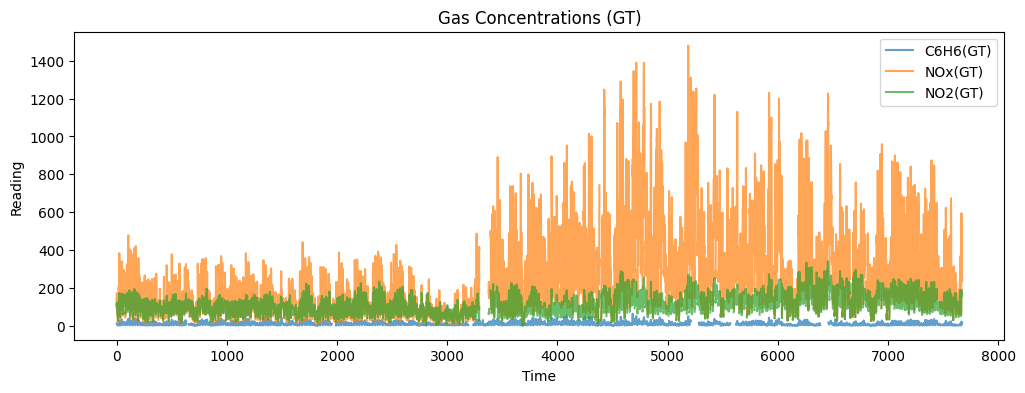

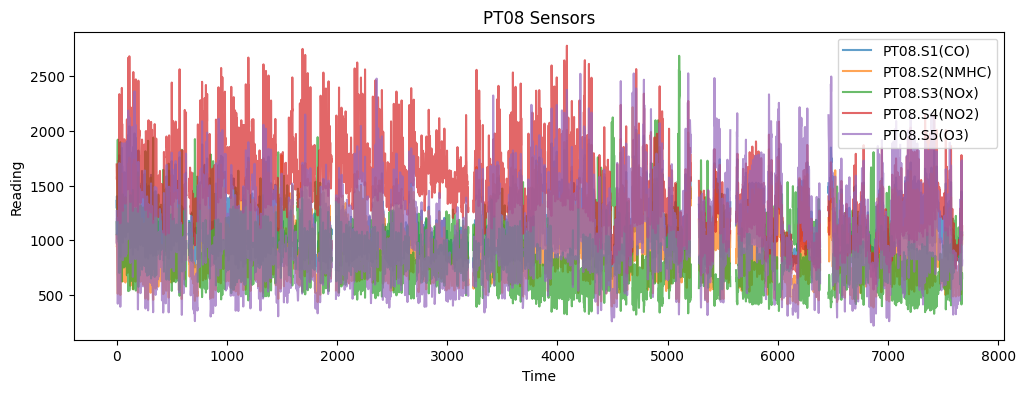

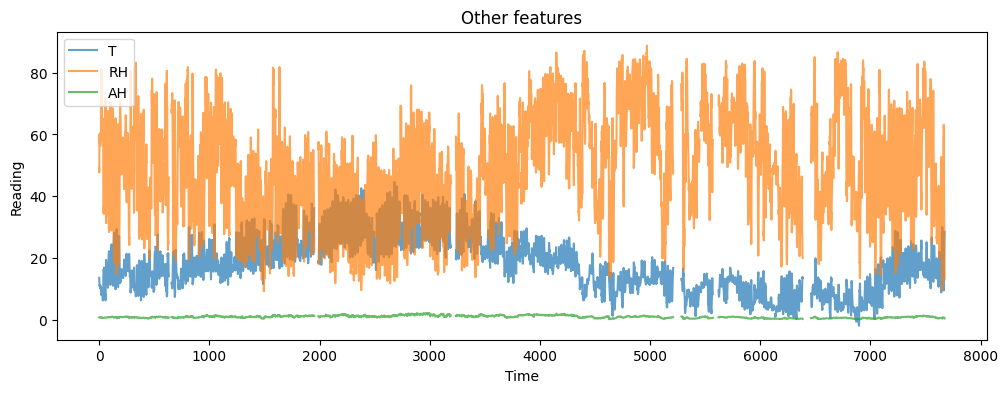

In [5]:
# plot the points of q1_raw["NOx(GT)"] and q1_raw["NO2(GT)"]

gt = ["C6H6(GT)", "NOx(GT)", "NO2(GT)"]

plt.figure(figsize=(12, 4))
for feature in gt:
    plt.plot(q1_raw[feature], label=feature, linestyle='-', markersize=3, alpha=0.7)
plt.title("Gas Concentrations (GT)")
plt.xlabel("Time")
plt.ylabel("Reading")
plt.legend()
plt.show()


pt08_sensors = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]

plt.figure(figsize=(12, 4))
for feature in pt08_sensors:
    plt.plot(q1_raw[feature], label=feature, linestyle='-', markersize=3, alpha=0.7)
plt.title("PT08 Sensors")
plt.xlabel("Time")
plt.ylabel("Reading")
plt.legend()
plt.show()

others = ["T", "RH", "AH"]

plt.figure(figsize=(12, 4))
for feature in others:
    plt.plot(q1_raw[feature], label=feature, linestyle='-', markersize=3, alpha=0.7)
plt.title("Other features")
plt.xlabel("Time")
plt.ylabel("Reading")
plt.legend()
plt.show()

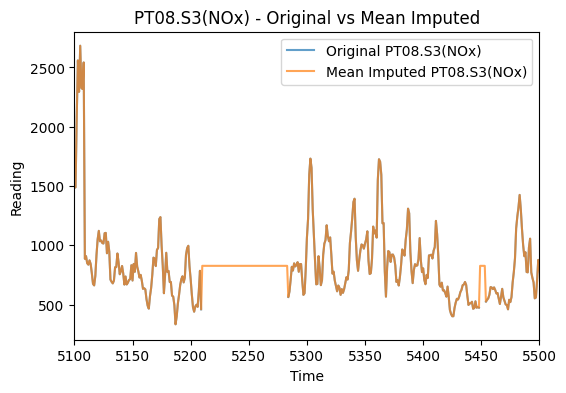

In [6]:
# Implementation of mean imputation
q1_imputed_mean = q1_raw.fillna(q1_raw.mean())

# Plot PT08.S3(NOx)
plt.figure(figsize=(6, 4))
plt.plot(q1_raw["PT08.S3(NOx)"], label="Original PT08.S3(NOx)", alpha=0.7)
plt.plot(q1_imputed_mean["PT08.S3(NOx)"], label="Mean Imputed PT08.S3(NOx)", alpha=0.7)
plt.title("PT08.S3(NOx) - Original vs Mean Imputed")
plt.xlabel("Time")
plt.ylabel("Reading")
plt.xlim(5100,5500)
plt.legend()
plt.show()

<h1 style="color:orange">A.b Missing Values Visualization</h1>

As shown by the graphs above, missing data points appear in sequential gaps rather than being spread randomly thorught the dataset. Furthermore, as shown by the NOx plot with mean imputed values, the imputation does not capture the variance of the sequential data. For this reason, using a mean/median based imputation technique will not suffice. 

Let's try a KNN based imputation technique to see if it captures the variance better.

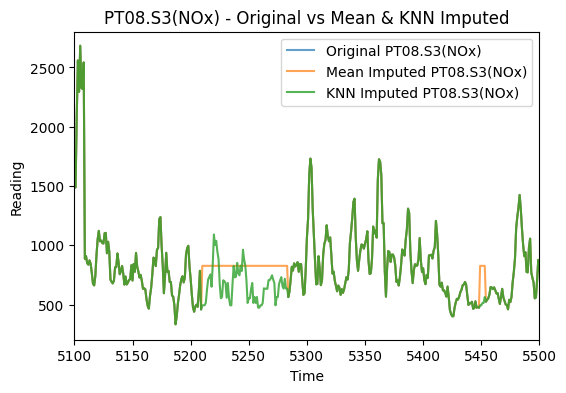

In [7]:
from sklearn.impute import KNNImputer

# configure and run KNN imputer (doesn't overwrite existing 'imputer' variable)
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform") # Setting k = 5 (tested simply with best looking results)
q1_knn_array = knn_imputer.fit_transform(q1_raw) # Impute
q1_knn_imputed = pd.DataFrame(q1_knn_array, columns=q1_raw.columns) # Convert back to DataFrame

# q1_knn_imputed.head()

# Plot PT08.S3(NOx)
plt.figure(figsize=(6, 4))
plt.plot(q1_raw["PT08.S3(NOx)"], label="Original PT08.S3(NOx)", alpha=0.7)
plt.plot(q1_imputed_mean["PT08.S3(NOx)"], label="Mean Imputed PT08.S3(NOx)", alpha=0.7)
plt.plot(q1_knn_imputed["PT08.S3(NOx)"], label="KNN Imputed PT08.S3(NOx)", alpha=0.8)
plt.title("PT08.S3(NOx) - Original vs Mean & KNN Imputed")
plt.xlabel("Time")
plt.ylabel("Reading")
plt.xlim(5100, 5500)
plt.legend()
plt.show()

<h1 style="color:orange">A.c Choosing KNN Imputation</h1>

Showing the same cross section of the data with both the KNN and mean imputation menthods, one can clearly see that KNN is able to capture the variance of the data much better. The largest visible gap in the data is between indices ~5200-5300 and KNN's imputations seem flawless in this region compared to the flat line of the mean imputation.

**KNN Imputation Chosen**


---

In [8]:
# drop all rows with NaNs in the original dataset

# q1_dropped = q1_raw.dropna()
# features = q1_raw.columns.drop('CO(GT)')

# q1_knn_imputed = q1_dropped.copy()

<h1 style="color:orange">B.a Correlations</h1>

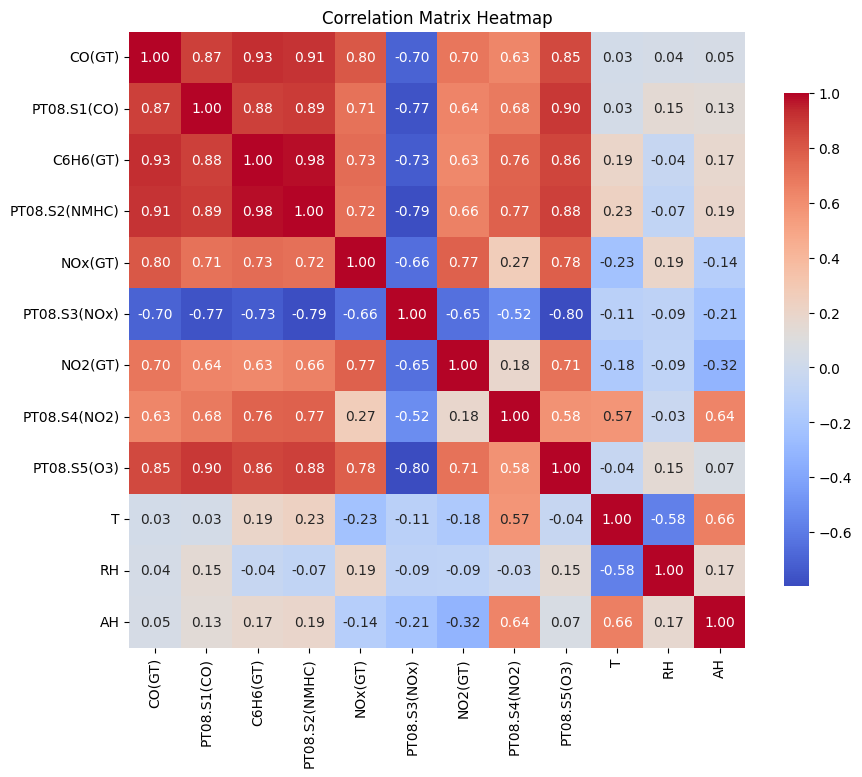

In [9]:
# Correlation matrix heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = q1_knn_imputed.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix Heatmap")
plt.show()

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define X using the imputed dataframe (exclude target CO(GT))
X = q1_knn_imputed[features].copy().astype(float)  # ensure numeric dtype

# Calculate VIF for each feature in X
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

          Feature         VIF
0     PT08.S1(CO)  199.345462
1        C6H6(GT)   69.540993
2   PT08.S2(NMHC)  431.268703
3         NOx(GT)   15.249597
4    PT08.S3(NOx)   22.581244
5         NO2(GT)   28.856246
6    PT08.S4(NO2)  266.913774
7     PT08.S5(O3)   66.841235
8               T   72.920026
9              RH   71.400425
10             AH   78.578512


<h1 style="color:orange">B.b Correlations and Multicollinearity</h1>

Most features are heavily correlated with the target, with the exception of T, RH, and AH. There is also generally significant multicollinearity. While this should usually be considered in feature selection, it is mostly important when one is looking for model interpretability. Since the goal of this model is to accurately predict CO(GT) levels without necessarily needing a n understanding of how each feature contributes to the prediction, multicollinearity is less of a concern. 

That being said, the VIF values of CO, NMHC, and NO2 are VERY high, while the correlation matrix shows that they are not significantly more correlated with the target than NOx. For this reason, I am noting the possibility and potential benefits of removing some of the high-VIF features.

---

<h1 style="color:orange">C.a Least Squares with All Features</h1>

In [11]:
q1_knn_imputed.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [12]:
# features = features.drop("PT08.S4(NO2)")

features

Index(['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
       'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')

In [13]:
"""
Splitting the data into 80-20 train-test sets (and some more preprocessing)
"""

X = q1_knn_imputed[features].values
y = q1_knn_imputed["CO(GT)"].values
    
# mean-imputed dataset instead of KNN-imputed
# X = q1_imputed_mean[features].values
# y = q1_imputed_mean["CO(GT)"].values

# scaling the data for consistency.
scaler_OLS = StandardScaler()
X_scaled_OLS = scaler_OLS.fit_transform(X) 
X = pd.DataFrame(X_scaled_OLS, columns=features).values # back to DF to work with splitter.

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0 
)

# type(X_train), type(y_train), X_train.shape, y_train.shape
X_train = pd.DataFrame(X_train, columns=features)
X_test = pd.DataFrame(X_test, columns=features)


In [14]:
X_train, y_train

(      PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  PT08.S3(NOx)   NO2(GT)  \
 0        0.320146  1.502192       1.470509  0.621085     -1.014317  1.201142   
 1       -0.119478 -0.262063      -0.120534 -0.328318     -0.406705 -0.857793   
 2        2.906986  1.475257       1.447834  2.674227     -1.436489  1.263534   
 3       -0.586867 -0.167790      -0.018495 -0.627637      0.654643 -0.525036   
 4       -1.105161 -0.544883      -0.475778 -0.856803      0.114105 -0.753806   
 ...           ...       ...            ...       ...           ...       ...   
 6134     1.652901  1.569530       1.515859  2.300078     -1.389142  0.286060   
 6135    -0.332348 -0.248596      -0.109196  0.087923     -0.540853 -0.441846   
 6136    -1.082023 -0.450610      -0.347285 -0.613606      1.009741 -0.504238   
 6137    -1.281010 -0.908508      -0.985970 -0.950340      0.646752 -1.148955   
 6138    -0.670164 -0.800767      -0.812127 -0.889541      0.425802 -0.899387   
 
       PT08.S4(NO2)  PT08.

In [15]:
# OLS
import statsmodels.api as sm

X_train_statsmodel = sm.add_constant(X_train)  # adding a constant because statsmodels does not do it automatically
# X_train_statsmodel = X_train  
lin_reg = sm.OLS(y_train, X_train_statsmodel).fit()

print(lin_reg.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     5724.
Date:                Fri, 28 Nov 2025   Prob (F-statistic):               0.00
Time:                        11:59:30   Log-Likelihood:                -3616.1
No. Observations:                6139   AIC:                             7256.
Df Residuals:                    6127   BIC:                             7337.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.1529      0.006    386.323

<h1 style="color:orange">C.b Model Summary:</h1>

CO and NO2 are repeat offenders. Both have high VIF values and in this model, relatively, they have a higher coefficient. An addition to this group is C6H6 with a much higher coefficient, meaning that it has a significant effect on the model's prediction. It makes sense that there would be a close relationship between CO and C6H6 as C6H6 can be found in fossil fuels and CO is a byproduct of fossil fuel combustion. However, because the presence of C6H6 is not necessarily a cause of CO presence and the fact that CO can exist without C6H6 (for example wood/coal burining), this high correlation is likely a dangerous example of multicollinearity. For this reason, it is considerable to drop this variable.

https://www.nhs.uk/conditions/carbon-monoxide-poisoning/


In [16]:
# Make predictions
y_pred_train = lin_reg.predict(X_train_statsmodel)
X_test_statsmodel = sm.add_constant(X_test) 
y_pred_test = lin_reg.predict(X_test_statsmodel)

# evaluate model performance
from sklearn.metrics import mean_squared_error, r2_score

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# print(f"Training Set: MSE = {mse_train}, R² = {r2_train}")
# print(f"Test Set: MSE = {mse_test}, R² = {r2_test}")

print("Model Evaluation:")

print(f"\nTraining Performance:")
print(f"  R²:   {r2_train}")
print(f"  MSE:  {mse_train}")

print(f"\nTest Performance):")
print(f"  R²:   {r2_test}")
print(f"  MSE:  {mse_test}")



# Pretty good performance on both sets. better MSE loss on the test set! wohooo


Model Evaluation:

Training Performance:
  R²:   0.9113190686953818
  MSE:  0.19017755060807454

Test Performance):
  R²:   0.911910382946201
  MSE:  0.17401830754248018


<h1 style="color:orange">D.a L1 and L2 Regularisation</h1>

In [17]:
# Scale the data for ridge regression
# scaler_L1 = StandardScaler()
# X_scaled_L1 = scaler_L1.fit_transform(X)

# X = pd.DataFrame(X_scaled_L1, columns=features).values # back to DF to work with model.

# Don't need to scale again, it was already done before.

# Creating log-scale
alphas = np.logspace(-6, 6, 200)  # From 0.001 to 1000

from sklearn.linear_model import RidgeCV, Ridge, LassoCV, Lasso

# ridge with cross-validatiosn
ridgeCV = RidgeCV(alphas=alphas, cv=10, scoring='neg_mean_squared_error')
ridgeCV.fit(X_train, y_train)

print(f"Best ridge alpha: {ridgeCV.alpha_}")




Best ridge alpha: 6.51733960488242


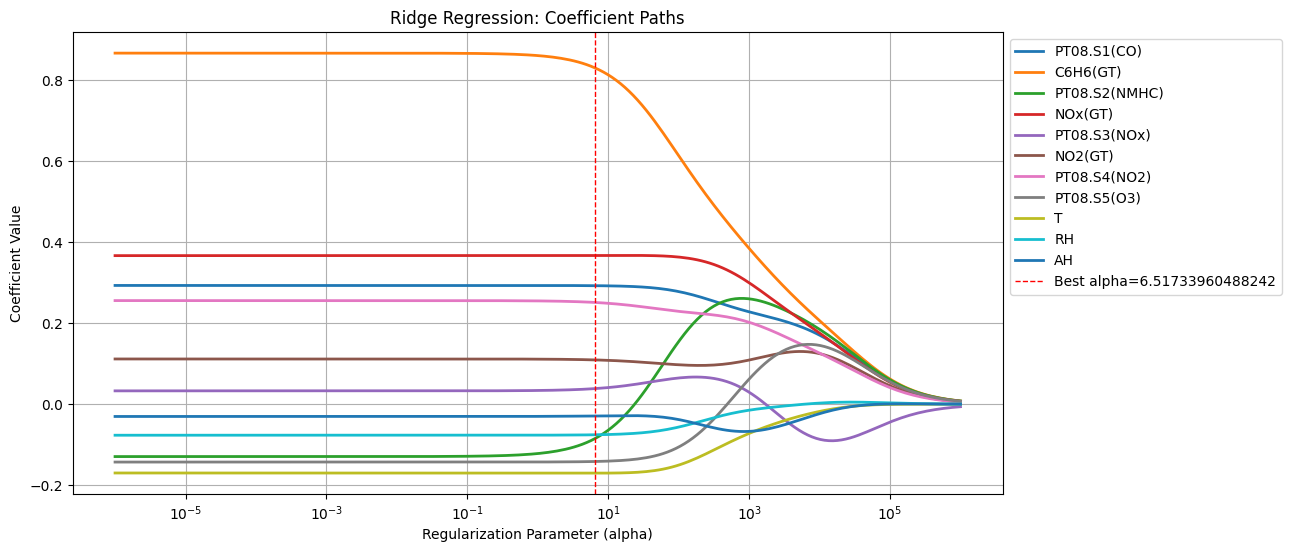

In [18]:
ridge_coefs = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)


plt.figure(figsize=(12, 6))

# Ridge coefficient path

for i, feature in enumerate(features):
    plt.plot(alphas, ridge_coefs[:, i], label=feature, linewidth=2)

plt.axvline(ridgeCV.alpha_, color='red', linestyle='--', linewidth=1, 
            label=f'Best alpha={ridgeCV.alpha_}')
plt.xscale('log')
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Paths')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)

In [19]:
# doing the same for lasso
lassoCV = LassoCV(alphas=alphas, cv=10)
lassoCV.fit(X_train, y_train)

print(f"Best lasso alpha: {lassoCV.alpha_}")

Best lasso alpha: 6.080224261649427e-06


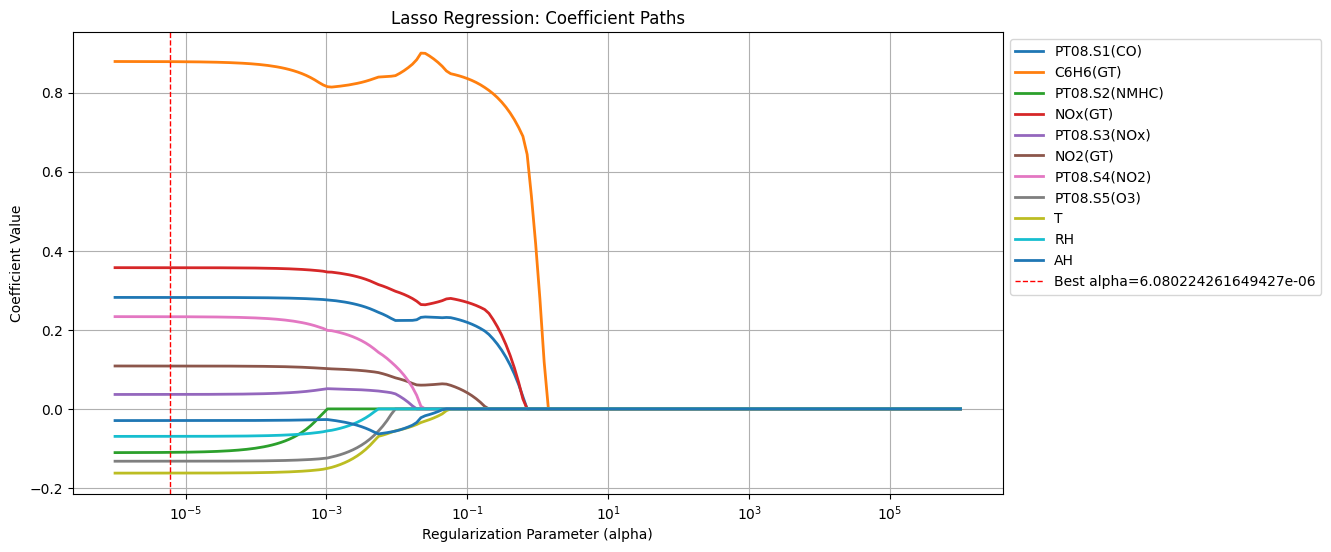

In [20]:
lasso_coefs = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(12, 6))
# Lasso coefficient path

for i, feature in enumerate(features):
    plt.plot(alphas, lasso_coefs[:, i], label=feature, linewidth=2)

plt.axvline(lassoCV.alpha_, color='red', linestyle='--', linewidth=1, 
            label=f'Best alpha={lassoCV.alpha_}')
plt.xscale('log')
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Paths')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True)

In [21]:
ridge_optimal = Ridge(alpha=ridgeCV.alpha_)
ridge_optimal.fit(X_train, y_train)

lasso_optimal = Lasso(alpha=lassoCV.alpha_, max_iter=10000)
lasso_optimal.fit(X_train, y_train)

,alpha,6.080224261649427e-06
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [22]:
coef_comparison = pd.DataFrame({
    'Plain_Coef': lin_reg.params.drop('const'), # before regularisation
    'Ridge_Coef': ridge_optimal.coef_,
    'Lasso_Coef': lasso_optimal.coef_,
})

print("Coefficient comparison at optimal regularisation vs without regularisation\n")
print(coef_comparison)


Coefficient comparison at optimal regularisation vs without regularisation

               Plain_Coef  Ridge_Coef  Lasso_Coef
PT08.S1(CO)      0.293371    0.292789    0.293333
C6H6(GT)         0.867004    0.830346    0.866597
PT08.S2(NMHC)   -0.129164   -0.084473   -0.128483
NOx(GT)          0.366989    0.367324    0.366930
PT08.S3(NOx)     0.033084    0.038689    0.033169
NO2(GT)          0.111835    0.109507    0.111791
PT08.S4(NO2)     0.255983    0.251375    0.255784
PT08.S5(O3)     -0.142710   -0.141310   -0.142665
T               -0.169680   -0.170019   -0.169612
RH              -0.076459   -0.075362   -0.076378
AH              -0.030153   -0.028820   -0.030139


In [23]:
y_pred_ridge = ridge_optimal.predict(X_test)
y_pred_lasso = lasso_optimal.predict(X_test)

In [24]:
y_pred_ridge = ridge_optimal.predict(X_test)
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)


In [25]:
y_pred_lasso = lasso_optimal.predict(X_test)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)


In [26]:
print("Model Comparison:\n")

print(f"Ridge Regression (alpha={ridgeCV.alpha_}):")
print(f"  R²:   {ridge_r2}")
print(f"  MSE:  {ridge_mse}")
print()
print(f"Lasso Regression (alpha={lassoCV.alpha_}):")
print(f"  R²:   {lasso_r2}")
print(f"  MSE:  {lasso_mse}")


Model Comparison:

Ridge Regression (alpha=6.51733960488242):
  R²:   0.9119342133113744
  MSE:  0.17397123139486714

Lasso Regression (alpha=6.080224261649427e-06):
  R²:   0.9119126313771252
  MSE:  0.174013865836895


<h1 style="color:orange">D.b Regularisation Evaluation</h1>

There is a very small improvement in both R² and MSE with both regularisation methods with ridge regression performing ever so slightly better than lasso. This is likely due to the more significant regularisation of the "PT08.S2(NMHC)" feature by ridge regression.

---
<h1 style="color:orange">E.a Polynomial Kernel Ridge Regression</h1>

  0%|          | 0/250 [00:00<?, ?it/s]

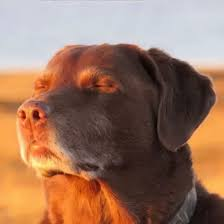

,estimator,ProgressBarKernelRidge()
,param_grid,"{'alpha': array([1.0000...00000000e+02]), 'degree': [2], 'kernel': ['polynomial']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.013257113655901095


In [27]:
# perform grid search to find the best alpha for the polynomial kernel ridge regression model
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

# My imports for progress bar + easter egg
from IPython.display import Image, display
from tqdm.auto import tqdm

alphas = np.logspace(-3, 2, 50)

param_grid = {'alpha': alphas,
'degree': [2],
'kernel': ['polynomial']}
cross_validations = 5

total_searches = (
    len(alphas) 
    *cross_validations 
    *len(param_grid['degree']) 
    *len(param_grid['kernel'])
)

pbar = tqdm(total=total_searches)

class ProgressBarKernelRidge(KernelRidge):

    def fit(self, X, y=None, **fit_params):
        pbar.update(1)
        return super().fit(X, y, **fit_params)


display(Image('./images.jpeg'))
grid_search = GridSearchCV(ProgressBarKernelRidge(), param_grid, cv=cross_validations, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

In [28]:
grid_search.best_params_['alpha']

0.013257113655901095

In [29]:
from sklearn.kernel_ridge import KernelRidge

kernel_ridge = KernelRidge(kernel='polynomial', degree=2, alpha=grid_search.best_params_['alpha']) # 6.51733960488242 from other model
kernel_ridge.fit(X_train, y_train)

y_pred_kernel_ridge = kernel_ridge.predict(X_test)


In [30]:
kernel_ridge_r2 = r2_score(y_test, y_pred_kernel_ridge)
kernel_ridge_mse = mean_squared_error(y_test, y_pred_kernel_ridge)


In [31]:
print(f"Kernel Ridge Regression (polynomial degree 2, alpha={grid_search.best_params_['alpha']}):")
print(f"  R²:   {kernel_ridge_r2}")
print(f"  MSE:  {kernel_ridge_mse}")


Kernel Ridge Regression (polynomial degree 2, alpha=0.013257113655901095):
  R²:   0.9199223829907162
  MSE:  0.15819084984192824


<h1 style="color:orange">E.b Model Evaluation</h1>

The polynomial kernel performed even better the linear models, although the jump in performance is not very significant as the linear models are already performing well. The polynomial kernel does hold higher predictive performance, as it is able to captutre and model more complex non-linear relationships in the featurespace.

---

<h1 style="color:orange">F.a RBF Kernel Ridge Regression</h1>


In [32]:
# Running an RBF kernel ridge regression model
rbf_kernel_ridge = KernelRidge(kernel='rbf', gamma=0.1, alpha=1.0)
rbf_kernel_ridge.fit(X_train, y_train)
y_pred_rbf_kernel_ridge = rbf_kernel_ridge.predict(X_test)
rbf_kernel_ridge_r2 = r2_score(y_test, y_pred_rbf_kernel_ridge)
rbf_kernel_ridge_mse = mean_squared_error(y_test, y_pred_rbf_kernel_ridge)
print(f"RBF Kernel Ridge Regression (gamma=0.1, alpha=1.0):")
print(f"  R²:   {rbf_kernel_ridge_r2}")
print(f"  MSE:  {rbf_kernel_ridge_mse}")

RBF Kernel Ridge Regression (gamma=0.1, alpha=1.0):
  R²:   0.9218415148669578
  MSE:  0.15439966431718677


500


  0%|          | 0/500 [00:00<?, ?it/s]

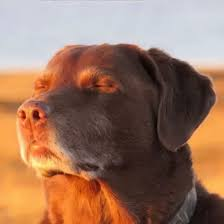

,estimator,ProgressBarKernelRidge()
,param_grid,"{'alpha': array([1.0000...00000000e+02]), 'degree': [2], 'gamma': array([1.0000...00000000e+02]), 'kernel': ['rbf']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01291549665014884


In [33]:
# display(Image('./images.jpeg'))


alphas = np.logspace(-3, 2, 10)
gammas = np.logspace(-3, 2, 10)
cross_validations = 5

param_grid = {'alpha': alphas,
'degree': [2],
'kernel': ['rbf'],
'gamma': gammas}

total_searches = (
    len(alphas) 
    *cross_validations 
    *len(param_grid['degree']) 
    *len(param_grid['kernel'])
    *len(param_grid['gamma'])
)

print(total_searches)

pbar = tqdm(total=total_searches)


# class ProgressBarKernelRidge(KernelRidge):

#     def fit(self, X, y=None, **fit_params):
#         pbar.update(1)
#         return super().fit(X, y, **fit_params)

display(Image('./images.jpeg'))
grid_search = GridSearchCV(ProgressBarKernelRidge(), param_grid, cv=cross_validations, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)



In [ ]:
rbf_kernel_ridge = KernelRidge(kernel='rbf', gamma=grid_search.best_params_['gamma'], alpha=grid_search.best_params_['alpha'])
rbf_kernel_ridge.fit(X_train, y_train)
y_pred_rbf_kernel_ridge = rbf_kernel_ridge.predict(X_test)
rbf_kernel_ridge_r2 = r2_score(y_test, y_pred_rbf_kernel_ridge)
rbf_kernel_ridge_mse = mean_squared_error(y_test, y_pred_rbf_kernel_ridge)
print(f"RBF Kernel Ridge Regression (gamma={grid_search.best_params_['gamma']}, alpha={grid_search.best_params_['alpha']}):")
print(f"  R²:   {rbf_kernel_ridge_r2}")
print(f"  MSE:  {rbf_kernel_ridge_mse}")

RBF Kernel Ridge Regression (gamma=0.046415888336127795, alpha=0.01291549665014884):
  R²:   0.9344362334093781
  MSE:  0.12951918829709774


<h1 style="color:orange">F.b Model Evaluation</h1>

Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

---

<h1 style="color:orange">G.a Model Comparisons</h1>



In [143]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dictionary to store all predictions
models = {
    'OLS': y_pred_test,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso,
    'Polynomial Kernel Ridge': y_pred_kernel_ridge,
    'RBF Kernel Ridge': y_pred_rbf_kernel_ridge
}

train_predictions = {
    'OLS': y_pred_train,
    'Ridge': ridge_optimal.predict(X_train),
    'Lasso': lasso_optimal.predict(X_train),
    'Polynomial Kernel Ridge': kernel_ridge.predict(X_train),
    'RBF Kernel Ridge': rbf_kernel_ridge.predict(X_train)
}

# Create performance summary
performance_summary = []


In [144]:
for model_name in models.keys():
    # In-sample metrics
    y_train_pred = train_predictions[model_name]
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # Out-of-sample metrics
    y_test_pred = models[model_name]
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    performance_summary.append({
        'Model': model_name,
        'Train R²': r2_train,
        'Train MAE': mae_train,
        'Train RMSE': rmse_train,
        'Test R²': r2_test,
        'Test MAE': mae_test,
        'Test RMSE': rmse_test
    })

# Create DataFrame for better visualization
performance_df = pd.DataFrame(performance_summary)
performance_df = performance_df.round(4)

print("Model Performance Comparison:\n")
print(performance_df.to_string(index=False))

Model Performance Comparison:

                  Model  Train R²  Train MAE  Train RMSE  Test R²  Test MAE  Test RMSE
                    OLS    0.9113     0.2718      0.4361   0.9119    0.2655     0.4172
                  Ridge    0.9113     0.2719      0.4361   0.9119    0.2653     0.4171
                  Lasso    0.9113     0.2718      0.4361   0.9119    0.2655     0.4171
Polynomial Kernel Ridge    0.9256     0.2512      0.3994   0.9197    0.2525     0.3983
       RBF Kernel Ridge    0.9461     0.2139      0.3400   0.9344    0.2304     0.3599


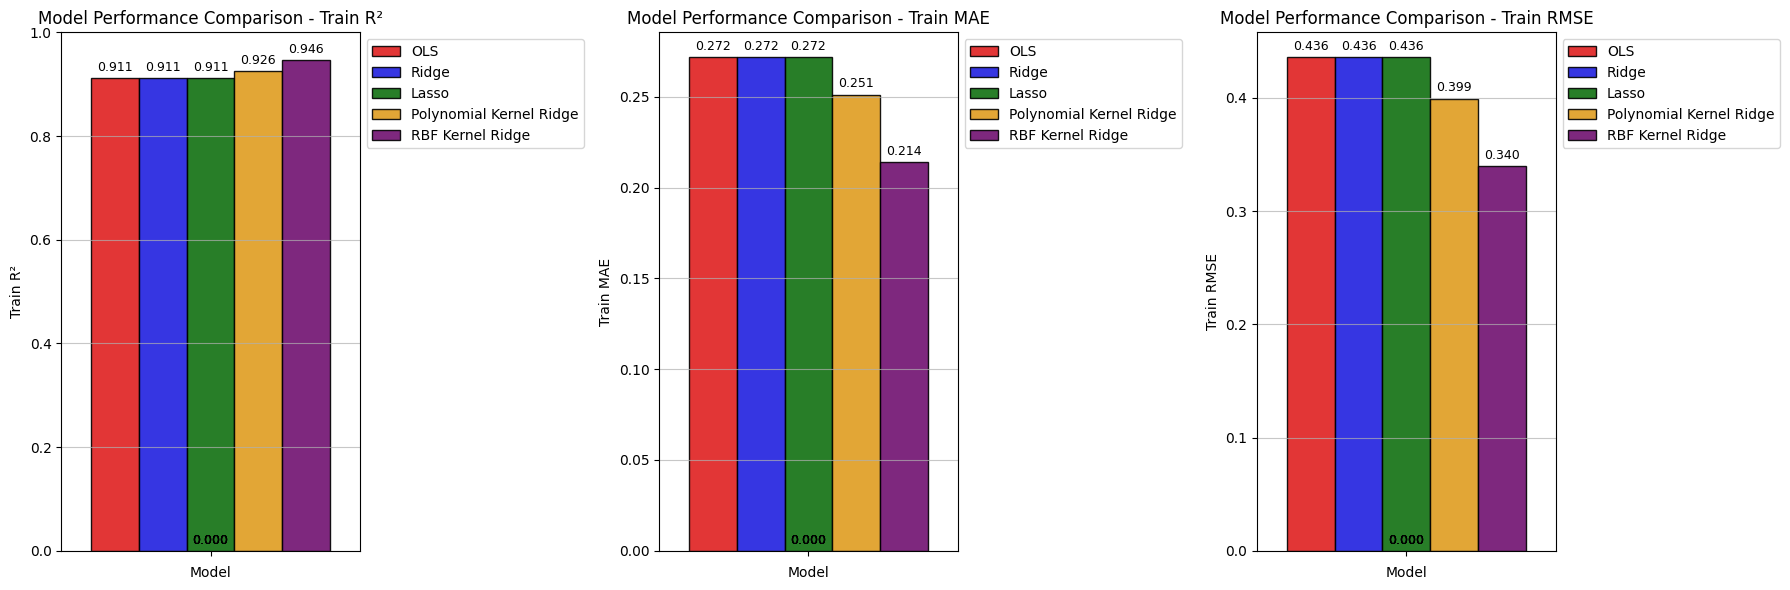

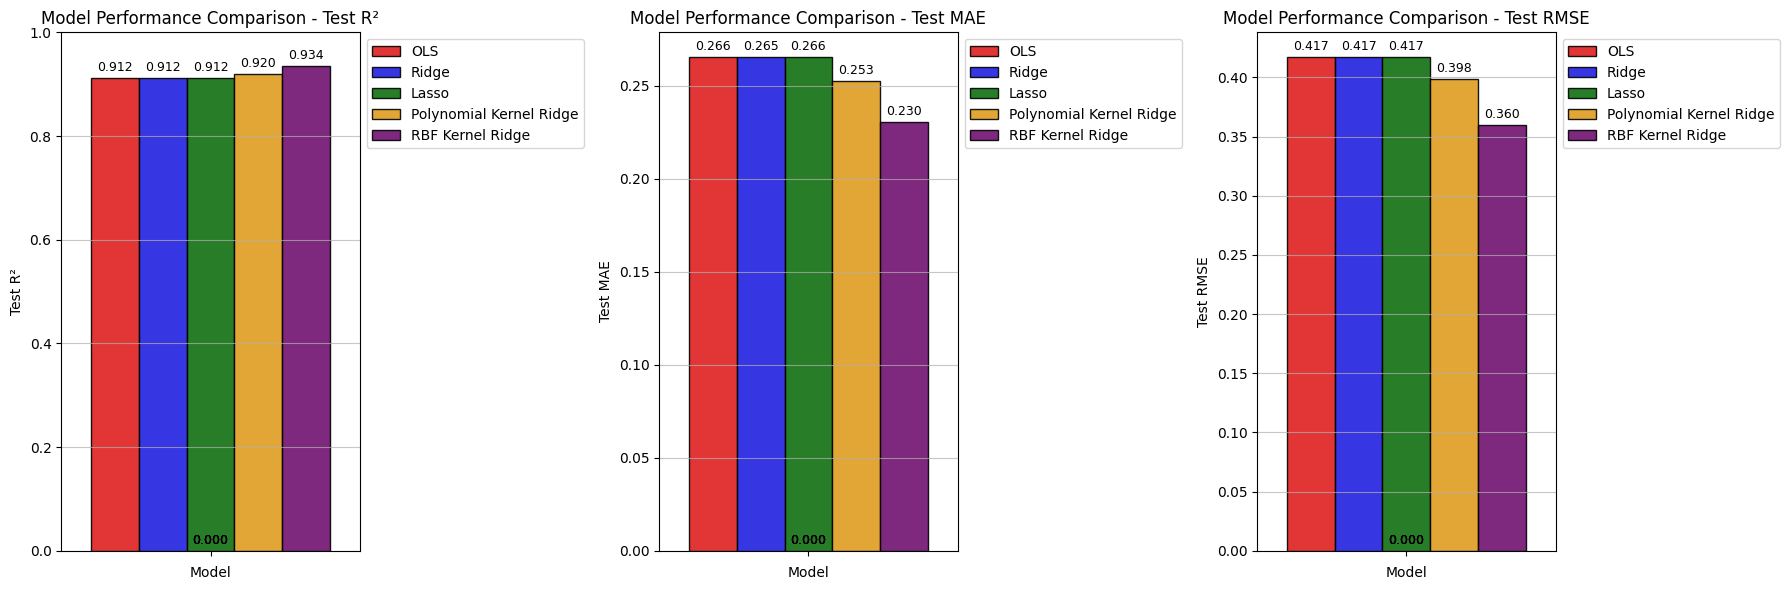

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

metrics = ['Train R²', 'Train MAE', 'Train RMSE']
titles = ['Model Performance Comparison - Train R²',
          'Model Performance Comparison - Train MAE',
          'Model Performance Comparison - Train RMSE']
ylims = [(0, 1), None, None]
palette = ['red', 'blue', 'green', 'orange', 'purple']

for ax, metric, title, ylim in zip(axes, metrics, titles, ylims):
    sns.barplot(hue='Model', y=metric, data=performance_df,
                palette=palette, alpha=0.9, edgecolor='black', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    ax.grid(True, alpha=0.7, axis='y')
    if ylim:
        ax.set_ylim(*ylim)
    # add value labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

metrics = ['Test R²', 'Test MAE', 'Test RMSE']
titles = ['Model Performance Comparison - Test R²',
          'Model Performance Comparison - Test MAE',
          'Model Performance Comparison - Test RMSE']
ylims = [(0, 1), None, None]
palette = ['red', 'blue', 'green', 'orange', 'purple']

for ax, metric, title, ylim in zip(axes, metrics, titles, ylims):
    sns.barplot(hue='Model', y=metric, data=performance_df,
                palette=palette, alpha=0.9, edgecolor='black', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    ax.grid(True, alpha=0.7, axis='y')
    if ylim:
        ax.set_ylim(*ylim)
    # add value labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


In [136]:
costs = {
    "PT08.S1(CO)": 1000,
    "PT08.S2(NMHC)": 800,
    "PT08.S3(NOx)": 700,
    "PT08.S4(NO2)": 700,
    "PT08.S5(O3)": 900,
    "T": 150,
    "RH": 150,
    "AH": 200,
    "NOx(GT)": 1800,
    "NO2(GT)": 1800,
    "C6H6(GT)": 2500,
}

# turn the dict into a pandas DF
costs_df = pd.DataFrame(list(costs.items()), columns=['Feature', 'Cost'])
costs_df

,Feature,Cost
0,PT08.S1(CO),1000
1,PT08.S2(NMHC),800
2,PT08.S3(NOx),700
3,PT08.S4(NO2),700
4,PT08.S5(O3),900
5,T,150
6,RH,150
7,AH,200
8,NOx(GT),1800
9,NO2(GT),1800


---
---

# Part 2: Detecting Cyber Attacks from Network Flows

In [19]:
q2_raw = pd.read_csv("data/q2.csv")

In [20]:
q2_raw.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow IAT Mean,Flow IAT Std,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Protocol,target
0,2,2,0,12.0,0.0,2.000000,0.000000,6.0,0.0,9.0,0.0,0.0,6,0
1,101,2,2,12.0,12.0,33.666667,56.580326,6.0,0.0,7.5,0.0,0.0,6,1
2,1,2,0,12.0,0.0,1.000000,0.000000,6.0,0.0,9.0,0.0,0.0,6,1
3,0,2,0,12.0,0.0,0.000000,0.000000,6.0,0.0,9.0,0.0,0.0,6,1
4,53,2,2,12.0,12.0,17.666667,28.005952,6.0,0.0,7.5,0.0,0.0,6,1


In [21]:
q2_raw.isna().sum()

Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Flow IAT Mean                  0
Flow IAT Std                   0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Protocol                       0
target                         0
dtype: int64

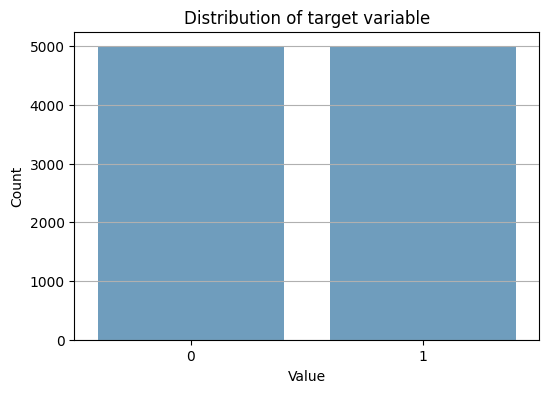

In [22]:
# class balance for target

# as a histogram
plt.figure(figsize=(6,4))
sns.barplot(x=q2_raw['target'].value_counts().index, y=q2_raw['target'].value_counts().values, alpha=0.7)
plt.title("Distribution of target variable")
plt.xlabel("Value")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()
    

<h1 style="color:orange">A.a Exploratory Analysis</h1>

The contains zero missing values and is evenly balanced between the two classes.

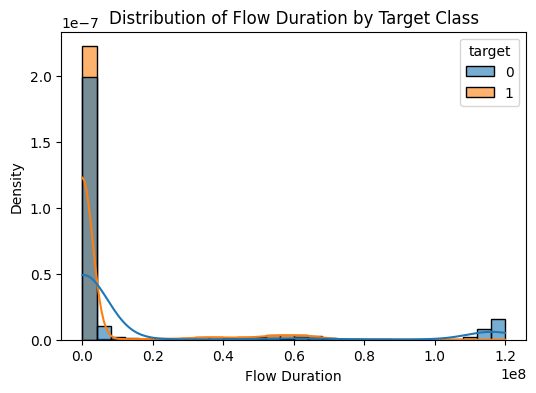

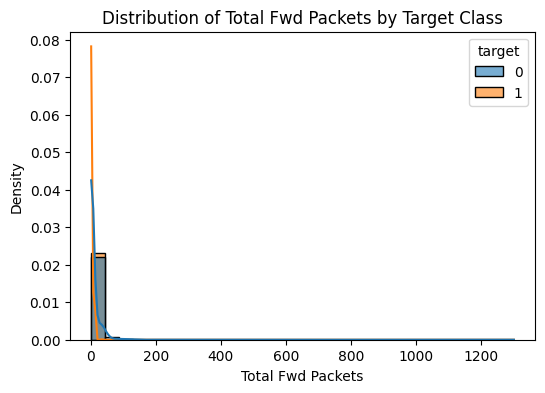

In [23]:
# plotting distributions of flow duration
plt.figure(figsize=(6,4))
sns.histplot(data=q2_raw, x='Flow Duration', hue='target', bins=30, kde=True, stat="density", common_norm=False, alpha=0.6)
plt.title("Distribution of Flow Duration by Target Class")
plt.xlabel("Flow Duration")
plt.ylabel("Density")
plt.show()

# plotting distributions of flow duration
plt.figure(figsize=(6,4))
sns.histplot(data=q2_raw, x='Total Fwd Packets', hue='target', bins=30, kde=True, stat="density", common_norm=False, alpha=0.6)
plt.title("Distribution of Total Fwd Packets by Target Class")
plt.xlabel("Total Fwd Packets")
plt.ylabel("Density")
plt.show()

<h1 style="color:orange">A.b Insight </h1>

INSIGHT ABOUT DATASET

---

<h1 style="color:orange">B.a Baseline Model</h1>

Fitting Logistic Regression.

In [33]:
# train test split

X = q2_raw.drop(columns=['target'])
y = q2_raw['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
# Logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_lr = LogisticRegression(max_iter=2000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
#
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.97      0.67      0.79      1000
           1       0.75      0.98      0.85      1000

    accuracy                           0.83      2000
   macro avg       0.86      0.83      0.82      2000
weighted avg       0.86      0.83      0.82      2000



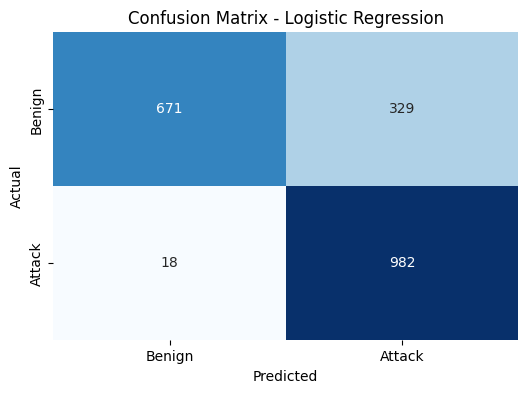

In [35]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign', 'Attack'], 
            yticklabels=['Benign', 'Attack'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

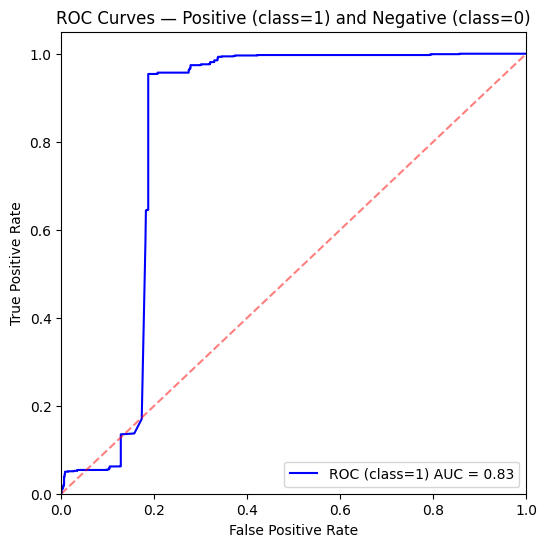

In [52]:
# ROC Curve
from sklearn.metrics import roc_curve, auc
prob_pos = model_lr.predict_proba(X_test)[:, 1] 

fpr_pos, tpr_pos, _ =  roc_curve(y_test, prob_pos)  # reuse existing arrays
roc_auc_pos = roc_auc = auc(fpr_pos, tpr_pos)

plt.figure(figsize=(6,6))
plt.plot(fpr_pos, tpr_pos, color='blue', label=f'ROC (class=1) AUC = {roc_auc_pos:.2f}')

plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Positive (class=1) and Negative (class=0)')
plt.legend(loc="lower right")
plt.show()

<h1 style="color:orange">B.b Baseline Model Evaluation</h1>

The confusion matrix shows a good performance on recall of attack flows. The ROC follows a good shape for both positives and negatives, with false 

---

<h1 style="color:orange">C.a Penalised Logistic Regression</h1>